# Task

- Train an **XGBoost Classifier** (using default parameters, no tuning).
- Perform **feature engineering** to improve model performance.
- Plot a **learning curve** to visualize model performance with varying training sizes.


In [1]:
# imports 
import pandas as pd
import os 
import sys
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath(".."))
from src.data_loader import load_data, load_data_from_file
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import VarianceThreshold
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA

from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.feature_selection import RFECV

from sklearn.model_selection import (
    cross_validate,
    cross_val_score,
    KFold,
    StratifiedKFold,
)
from sklearn.utils.class_weight import compute_sample_weight

from sklearn.metrics import (
    accuracy_score,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    auc,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    ConfusionMatrixDisplay
)
import xgboost as xgb
from tqdm import tqdm


# Data import 

In [2]:
location = '../data/raw/'
df = load_data_from_file(file_path=os.path.join(location, 'SantanderCustomerSatisfaction.csv'))

def tweak_df(df):
    df = df.copy()
    df['target'] = df['target'].astype('category')
    return df
df = tweak_df(df)

Loading dataset from file: ../data/raw/SantanderCustomerSatisfaction.csv...


# Train test split

In [3]:
(
    df_train,
    df_test,
    y_train,
    y_test,
) = train_test_split(
    df.drop(columns=['target']),
    df['target'],
    test_size=0.2,
    random_state=42,
    stratify=df['target'],
)

# XGBoost

In [4]:
def run_cv(estimator, X, y, cv, verbose=2):
    return cross_validate(
        estimator=estimator,
        X=X,
        y=y,
        cv=cv,
        scoring=("roc_auc", "average_precision"),
        return_estimator=True,
        return_indices=True,
        return_train_score=True,
        verbose=verbose,
    )
    
def print_test_scores(cv_results, scorings=("test_roc_auc", "test_average_precision")):
    for score in scorings:
        print(
            f"mean {score:30s} score = {cv_results[score].mean():.5f} +/- {cv_results[score].std():.5f}"
        )
        
def print_train_scores(cv_results, scorings=("train_roc_auc", "train_average_precision")):
    for score in scorings:
        print(
            f"mean {score:30s} score = {cv_results[score].mean():.5f} +/- {cv_results[score].std():.5f}"
        )
    

### Training XGBoost with default parameters

In [5]:
p_xgb = make_pipeline(
    xgb.XGBClassifier(
        random_state=42,
    )
)
cv = StratifiedKFold(
    n_splits=4, 
    shuffle=False, 
)
cv_results_xgb = run_cv(p_xgb, df_train, y_train, cv, verbose=3)

[Parallel(n_jobs=1)]: Done   0 out of   1 | elapsed:    2.5s remaining:    2.5s


KeyboardInterrupt: 

In [8]:
print_train_scores(cv_results_xgb)
print_test_scores(cv_results_xgb)

mean train_roc_auc                  score = 0.98903 +/- 0.00043
mean train_average_precision        score = 0.95186 +/- 0.00084
mean test_roc_auc                   score = 0.85447 +/- 0.00327
mean test_average_precision         score = 0.49209 +/- 0.00834


## Feature Selection

In this section i will try to do feature selection by removing the features that have almost no variation

<Axes: xlabel='variance of features', ylabel='Frequency'>

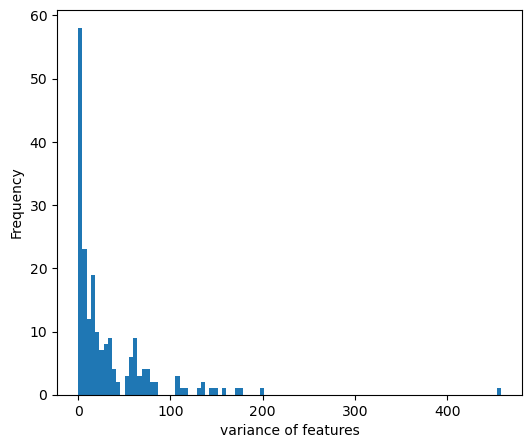

In [21]:
(
    df.describe().T['std'].pow(2)
    .plot(
        kind='hist',
        figsize=(6,5),
        bins=100,
        xlabel='variance of features',)
)

In [13]:
(
    df
    .describe().T['std']
    .pow(2)
    .sort_values(ascending=True)
    #.head(10)
)

var_68       0.000052
var_91       0.023299
var_108      0.029272
var_103      0.034232
var_12       0.036123
              ...    
var_97     159.829825
var_90     172.996399
var_117    176.827823
var_74     199.165216
var_45     458.170238
Name: std, Length: 200, dtype: float64

In [7]:
(
    df
    .describe()
    .T['std']
    .pow(2)
    .sort_values(ascending=True)
    .lt(0.1)
    .sum()
)

np.int64(10)

In [ ]:
p_xgb_var = make_pipeline(
    VarianceThreshold(threshold=0.1),   
    xgb.XGBClassifier(
        random_state=42,  
    )
)
cv_results_xgb_var = run_cv(p_xgb_var, df_train, y_train, cv, verbose=0)


In [16]:
print_train_scores(cv_results_xgb_var)
print_test_scores(cv_results_xgb_var)

mean train_roc_auc                  score = 0.98786 +/- 0.00031
mean train_average_precision        score = 0.94636 +/- 0.00125
mean test_roc_auc                   score = 0.84877 +/- 0.00185
mean test_average_precision         score = 0.47355 +/- 0.00460


mean test_roc_auc                   score = 0.84877 +/- 0.00185
mean test_average_precision         score = 0.47355 +/- 0.00460


It seems that variance threshold is not affecting the model performance. I will pursue with feature importance

# Feature importance 

In [20]:
p_xgb.fit(df_train, y_train)
xgb_model = p_xgb.named_steps["xgbclassifier"]
importance_dict = {}
df_imp = pd.DataFrame(
        xgb_model.get_booster().get_score(importance_type='gain').items(),
        columns=["feature", "importance"]
    ).sort_values(by="importance", ascending=False)
    
    # Convert to percentage
df_imp["importance_percent"] = 100 * df_imp["importance"] / df_imp["importance"].sum()
    
importance_dict[imp] = df_imp
    
result = permutation_importance(
    p_xgb,
    df_test, y_test,
    n_repeats=5,
    random_state=42,
    scoring="average_precision"
)
perm_importance_df = pd.DataFrame({
    "feature": df_test.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
}).sort_values(by="importance_mean", ascending=False)
N = [80, 120, 140, 160]

p_xgb_top = make_pipeline(
    xgb.XGBClassifier(
        random_state=42,
    )
)
cv = StratifiedKFold(
    n_splits=4, 
    shuffle=True,
    random_state=42, 
)
for n in N:
    top_features = perm_importance_df.head(n)["feature"].tolist()
    df_train_top = df_train[top_features]
    cv_results_xgb_top = run_cv(p_xgb, df_train_top, y_train, cv, verbose=0)
    print(f"Results for top {n} features:")
    print_train_scores(cv_results_xgb_top)
    print_test_scores(cv_results_xgb_top)
    print("--------------------------------------------------")

Results for top 80 features:
mean train_roc_auc                  score = 0.97451 +/- 0.00097
mean train_average_precision        score = 0.89803 +/- 0.00282
mean test_roc_auc                   score = 0.84358 +/- 0.00244
mean test_average_precision         score = 0.46540 +/- 0.00295
--------------------------------------------------
Results for top 120 features:
mean train_roc_auc                  score = 0.98492 +/- 0.00059
mean train_average_precision        score = 0.93461 +/- 0.00239
mean test_roc_auc                   score = 0.85402 +/- 0.00292
mean test_average_precision         score = 0.48652 +/- 0.00654
--------------------------------------------------
Results for top 140 features:
mean train_roc_auc                  score = 0.98682 +/- 0.00016
mean train_average_precision        score = 0.94208 +/- 0.00089
mean test_roc_auc                   score = 0.85466 +/- 0.00341
mean test_average_precision         score = 0.49085 +/- 0.00547
-----------------------------------------

Its clear that we cant see any intersection using different importance types. Also we can see that it is distributed over the whole dataset

In [33]:
N = [80, 120, 140, 160]

p_xgb_top = make_pipeline(
    xgb.XGBClassifier(
        random_state=42,
    )
)
cv = StratifiedKFold(
    n_splits=5, 
    shuffle=True, 
)
for n in N:
    top_features = perm_importance_df.head(n)["feature"].tolist()
    df_train_top = df_train[top_features]
    cv_results_xgb_top = run_cv(p_xgb, df_train_top, y_train, cv, verbose=0)
    print(f"Results for top {n} features:")
    print_train_scores(cv_results_xgb_top)
    print_test_scores(cv_results_xgb_top)
    print("--------------------------------------------------")

Results for top 80 features:
mean train_roc_auc                  score = 0.97238 +/- 0.00081
mean train_average_precision        score = 0.88928 +/- 0.00160
mean test_roc_auc                   score = 0.84443 +/- 0.00274
mean test_average_precision         score = 0.46867 +/- 0.00430
--------------------------------------------------
Results for top 120 features:
mean train_roc_auc                  score = 0.98249 +/- 0.00065
mean train_average_precision        score = 0.92552 +/- 0.00175
mean test_roc_auc                   score = 0.85452 +/- 0.00330
mean test_average_precision         score = 0.49033 +/- 0.00916
--------------------------------------------------
Results for top 140 features:
mean train_roc_auc                  score = 0.98466 +/- 0.00032
mean train_average_precision        score = 0.93365 +/- 0.00161
mean test_roc_auc                   score = 0.85597 +/- 0.00248
mean test_average_precision         score = 0.49369 +/- 0.00486
-----------------------------------------

with top 140 features we get the highest score for average precision. From now on, i will use the top 140 features for training. Now i will try recursive feature elimination.

In [ ]:
top_140_features = perm_importance_df.head(140)["feature"].to_list()
df_train_top = df_train[perm_importance_df.head(140)["feature"].tolist()]


In [24]:
cv = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=42,
)

rfecv = RFECV(
    estimator=xgb.XGBClassifier(random_state=42),  
    step=20,          # remove 20 features per iteration
    cv=StratifiedKFold(n_splits=4, shuffle=True),
    scoring="average_precision",
    min_features_to_select=50,
    n_jobs=-1
)
rfecv.fit(df_train, y_train)
selected_features = df_train.columns[rfecv.support_]
print(f"Optimal number of features: {rfecv.n_features_}")

Optimal number of features: 160


In [25]:
df_train_selected = df_train[selected_features]
cv_results_selected = run_cv(p_xgb, df_train_selected, y_train, cv, verbose=3)

[CV] END  average_precision: (train=0.947, test=0.487) roc_auc: (train=0.988, test=0.854) total time=  13.8s
[CV] END  average_precision: (train=0.945, test=0.490) roc_auc: (train=0.987, test=0.858) total time=  13.7s
[CV] END  average_precision: (train=0.946, test=0.485) roc_auc: (train=0.988, test=0.856) total time=  12.6s
[CV] END  average_precision: (train=0.948, test=0.473) roc_auc: (train=0.988, test=0.853) total time=  12.0s


[Parallel(n_jobs=1)]: Done   4 out of   4 | elapsed:   53.5s finished


In [26]:
print_train_scores(cv_results_selected)
print_test_scores(cv_results_selected)

mean train_roc_auc                  score = 0.98783 +/- 0.00022
mean train_average_precision        score = 0.94684 +/- 0.00125
mean test_roc_auc                   score = 0.85514 +/- 0.00183
mean test_average_precision         score = 0.48375 +/- 0.00661


## Findings

- Feature selection using **permutation importance** showed the most promising results.  
- Other methods did not achieve better performance.


Since PCA is a method that tries to captures the maximum variation of data to reduce the dimensionality, i will try to use this one to find 95% of explained variance using the reduced dataset, then use these new features for xgboost.

In [40]:
pca = PCA(n_components=0.95, random_state=42)
df_pca = pca.fit_transform(df_train_top)


In [41]:
df_train_pca = pd.DataFrame(df_pca, columns=[f'pca_{i}' for i in range(df_pca.shape[1])])
df_train_pca = pd.concat([df_train_pca,df_train.reset_index(drop=True)], axis=1)
df_train_pca


,pca_0,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6,pca_7,pca_8,pca_9,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,-15.305908,8.583152,15.284841,10.967407,-11.285320,7.907931,-10.271921,0.743308,1.636473,13.211994,...,-2.8810,8.1647,1.0927,2.1215,17.6536,3.2253,-2.1234,8.9516,13.3485,-16.0178
1,-15.621102,21.081351,25.852382,-7.998597,-3.300224,2.088144,4.814420,-5.073623,-1.671795,-6.427273,...,0.2397,8.1569,-1.0753,5.4679,23.6376,-0.5022,9.2414,8.2427,10.7546,-3.4394
2,-8.792134,-21.973682,-1.984472,-8.102579,-7.572869,-7.801421,-6.887468,-6.143004,-8.564307,-19.893458,...,8.1638,9.2399,1.0160,7.4548,17.0933,0.0715,-4.0455,9.4586,17.8789,-13.9784
3,-7.557168,-9.599797,18.424069,-13.788700,-3.193335,4.097490,-5.533611,15.880646,-2.882360,3.933171,...,9.3914,7.5576,0.4784,1.2138,19.0498,-1.5634,7.3092,8.4344,18.1104,-7.7668
4,-11.274176,-7.697240,-13.249227,21.445170,17.210640,3.400338,4.954875,8.482394,0.263945,10.543344,...,8.4802,0.9951,3.9973,1.9370,24.4786,-2.0294,-0.5454,8.7461,21.3832,14.1786
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159995,-24.951867,13.357436,-7.188512,17.541464,-13.933185,-8.272488,14.222970,9.788280,-7.724275,0.676326,...,4.9773,7.5440,0.8520,4.9402,19.0033,1.5157,-9.3063,9.0586,14.9677,-11.2478
159996,-5.730447,-5.014750,9.978150,4.906568,-14.803836,6.949062,-13.926597,-5.518855,-13.483265,21.941097,...,2.3344,13.5478,3.1656,-1.5778,17.3154,-0.9673,4.9180,8.8015,13.2019,-21.5102
159997,-11.347224,11.310731,-4.976587,7.025331,-0.843324,2.216024,6.585570,2.777748,-0.877558,-3.445480,...,5.7440,11.3343,2.8999,4.8399,14.0429,0.5310,-0.0909,6.7786,13.0894,-0.6329
159998,9.428722,15.833472,-17.167077,-0.944129,9.641669,-8.485820,2.423880,1.638179,16.752272,15.931109,...,2.3471,2.6189,4.6409,9.0566,15.5558,-0.0071,1.0802,9.6420,14.3480,4.5444


In [42]:
p_xgb_pca = make_pipeline(
    xgb.XGBClassifier(
        random_state=42,
    )
)
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)
cv_results_xgb_pca = run_cv(p_xgb_pca, df_train_pca, y_train, cv, verbose=0)

In [43]:
print_train_scores(cv_results_xgb_pca)

mean train_roc_auc                  score = 0.98778 +/- 0.00016
mean train_average_precision        score = 0.94643 +/- 0.00073


In [44]:
print_test_scores(cv_results_xgb_pca)

mean test_roc_auc                   score = 0.85328 +/- 0.00442
mean test_average_precision         score = 0.48331 +/- 0.00829


this also brought nothing to the performance. Now i will try to build rowwise aggregations and see both top features and whole dataset

In [45]:
df_train_agg = df_train.copy()
df_train_agg['feat_mean'] = df_train_agg.mean(axis=1)
df_train_agg['feat_sum']  = df_train_agg.sum(axis=1)
df_train_agg['feat_std']  = df_train_agg.std(axis=1)
df_train_agg['feat_max']  = df_train_agg.max(axis=1)
df_train_agg['feat_min']  = df_train_agg.min(axis=1)

In [46]:
p_xgb_agg = make_pipeline(
    xgb.XGBClassifier(
        random_state=42,
    )  
) 
cv = StratifiedKFold(
    n_splits=5, 
    shuffle=True,
    random_state=42,
)
cv_results_xgb_agg = run_cv(p_xgb_agg, df_train_agg, y_train, cv, verbose=0)

In [47]:
print_train_scores(cv_results_xgb_agg)

mean train_roc_auc                  score = 0.98763 +/- 0.00034
mean train_average_precision        score = 0.94548 +/- 0.00116


In [48]:
print_test_scores(cv_results_xgb_agg)

mean test_roc_auc                   score = 0.85588 +/- 0.00386
mean test_average_precision         score = 0.48963 +/- 0.00913


In [49]:
df_train_top_agg = df_train_top.copy()
df_train_top_agg['feat_mean'] = df_train_top_agg.mean(axis=1)
df_train_top_agg['feat_sum']  = df_train_top_agg.sum(axis=1)
df_train_top_agg['feat_std']  = df_train_top_agg.std(axis=1)
df_train_top_agg['feat_max']  = df_train_top_agg.max(axis=1)
df_train_top_agg['feat_min']  = df_train_top_agg.min(axis=1)

In [50]:
p_xgb_agg = make_pipeline(
    xgb.XGBClassifier(
        random_state=42,
    )  
) 
cv = StratifiedKFold(
    n_splits=5, 
    shuffle=True,
    random_state=42,
)
cv_results_xgb_agg = run_cv(p_xgb_agg, df_train_top_agg, y_train, cv, verbose=0)

In [51]:
print_train_scores(cv_results_xgb_agg)

mean train_roc_auc                  score = 0.98460 +/- 0.00045
mean train_average_precision        score = 0.93438 +/- 0.00139


In [52]:
print_test_scores(cv_results_xgb_agg)

mean test_roc_auc                   score = 0.85543 +/- 0.00390
mean test_average_precision         score = 0.48952 +/- 0.00841


Using the **top features** combined with the **generated features** resulted in a slight improvement in the average precision (AP) score.  

I will use this dataset in further tasks. Now i will try to adjust the xgboost parameters.


## Progress Summary  

So far, I’ve experimented with several techniques to improve the model’s performance.  
However, the best results still come from using the **top 140 features** together with the **generated aggregate features**.  

### Methods Tried
- **Feature Selection**: RFECV, permutation importance  
- **Dimensionality Reduction**: PCA (95% explained variance)  
- **Low-Variance Filtering**: Variance threshold  
- **Class Imbalance Handling**: Adjusted class weights (`scale_pos_weight`)  
- **Feature Engineering**: Created aggregate features (mean, sum, std, max, min)  

👉 None of these approaches have surpassed the performance achieved with **140 selected features using RFECV + generated features**.


## Roadmap – Next 2 Steps

### 1. Hyperparameter Optimization for XGBoost
Your model is likely not yet fully tuned — default parameters often underperform.  

Use **Optuna** or **RandomizedSearchCV** to tune critical parameters:

- `max_depth`, `min_child_weight` → control overfitting  
- `learning_rate`, `n_estimators` → balance bias vs variance  
- `subsample`, `colsample_bytree` → prevent overfitting, add randomness  
- `scale_pos_weight` → directly handle class imbalance  

Start with a coarse randomized search and then refine with Optuna.  
This usually provides the **biggest performance gain** in competitions.

---

### 2. Advanced Sampling / Ensemble Approaches
Since your dataset is highly imbalanced, handling class imbalance may require more than `scale_pos_weight`.  

Try **stratified resampling methods**:

- **SMOTE** (synthetic minority oversampling) or **ADASYN** to generate positive samples  
- **Undersampling** of negatives + XGBoost ensemble (bagging undersampled sets)  

 

These strategies help the model **focus on the positive class** without being overwhelmed by negatives.


## ⚠️ What is partially done or not done

### Learning curves / small sample evaluation
- You didn’t explicitly plot or check learning curves to see if a smaller subset of data gave meaningful results.

### Hyperparameter optimization
- You mostly used default XGBoost parameters.  
- Fine-tuning with Optuna or RandomizedSearchCV hasn’t been done yet.

### Comparison of multiple ML models
- You only used XGBoost.  
- No other models like Random Forest, Logistic Regression, or Gradient Boosting were tried.



ROC-AUC = 0.85447 ± 0.00327
Average Precision = 0.49209 ± 0.00834